  Thinning (factor=2): kept 51 points
Loaded delta-100-0.out: angle=0.0°, Fx=2.513e+01, Fy=0.000e+00, n_points=51
Added experimental noise: 2% of peak |data|=0.2492 -> sigma_noise_added=0.004984, realized sigma_noise=0.003793 
Automatic sigma prior scale: max fitted displacement=0.249177, 10% max displacement=0.0249177, beta=1/(10% max displacement)=40.1321
sigma_noise prior: Exp(beta=40.13)
Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\data_vs_noise.pdf


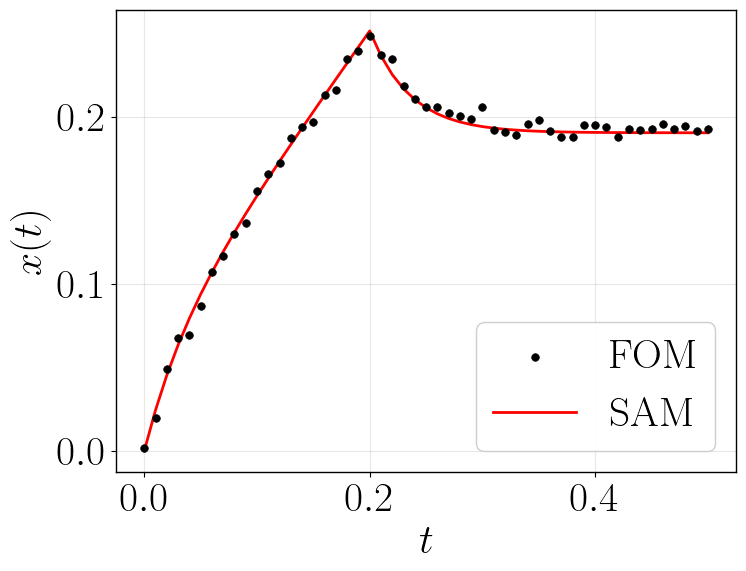

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\prior.pdf


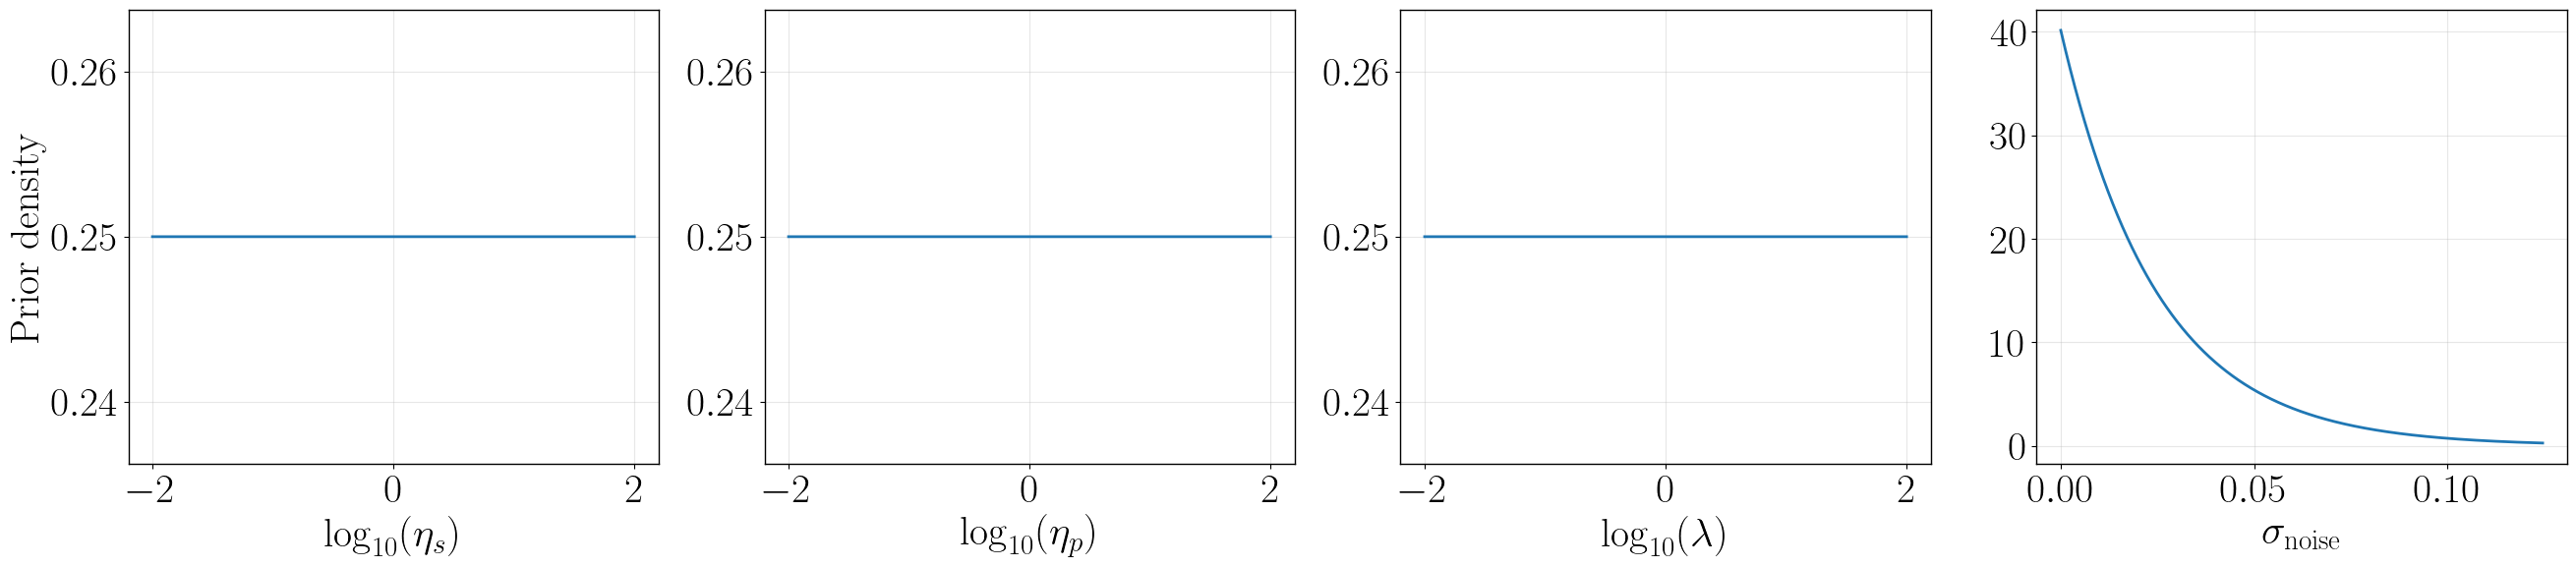


Preparing MCMC: ndim=4, walkers=8, steps=10000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [ 0.08378568 14.71914728  0.1326963   0.02510312]
  01: [ 0.09004086 10.12269405  9.84256419  0.0252676 ]
  02: [4.91364294 0.10609342 0.07439071 0.02253714]
  03: [ 8.58588085 15.56399941 23.81177427  0.02650237]
  04: [0.05208981 0.12511517 0.10854034 0.02355784]
  05: [9.5318828  9.40130168 0.14595933 0.02560689]
  06: [17.19866075  0.16052796  7.54213758  0.02662402]
  07: [ 0.16364946  0.08713658 12.1170665   0.02457918]

Warm-up: 1000 steps x 8 walkers


Warm-up:   0%|          | 0/1000 [00:00<?, ?it/s]


Walkers after warm-up (physical):
  00: [0.55430318 0.93711764 0.08891363 0.00280506]
  01: [0.44073537 0.98085217 0.10097369 0.00393153]
  02: [0.49576614 1.02084968 0.12278638 0.00356453]
  03: [0.50997364 0.80540241 0.08526286 0.00371245]
  04: [0.50691507 0.92767939 0.09388917 0.00337452]
  05: [0.62838621 0.76202873 0.07201775 0.00401408]
  06: [0.43813783 0.88404549 0.12602098 0.00375112]
  07: [0.53954902 0.62467907 0.1147629  0.00404079]


MCMC:   0%|          | 0/10000 [00:00<?, ?it/s]


MCMC Diagnostics Summary
Chains: 8  |  Samples/chain after burn-in: 7000  |  Total: 56000
----------------------------------------------------------------
Parameter                Mean            Std       Rhat
----------------------------------------------------------------
eta_s              5.3229e-01     1.6973e-02     1.0059
eta_p_eff          8.5535e-01     1.5166e-02     1.0059
lambda             1.0052e-01     3.7952e-03     1.0046
sigma_noise        3.8791e-03     4.1825e-04     1.0037
----------------------------------------------------------------
Mean Rhat                                        1.0050
Std Rhat                                         0.0010
----------------------------------------------------------------
Derived quantities
G                  8.5244e+00     4.1884e-01     1.0053
  G = eta_p_eff / lambda

All parameters show good convergence (Rhat <= 1.1)


Posterior-predictive adequacy (replicated data):
  Nominal central coverage of band:  95.0%
  ---------

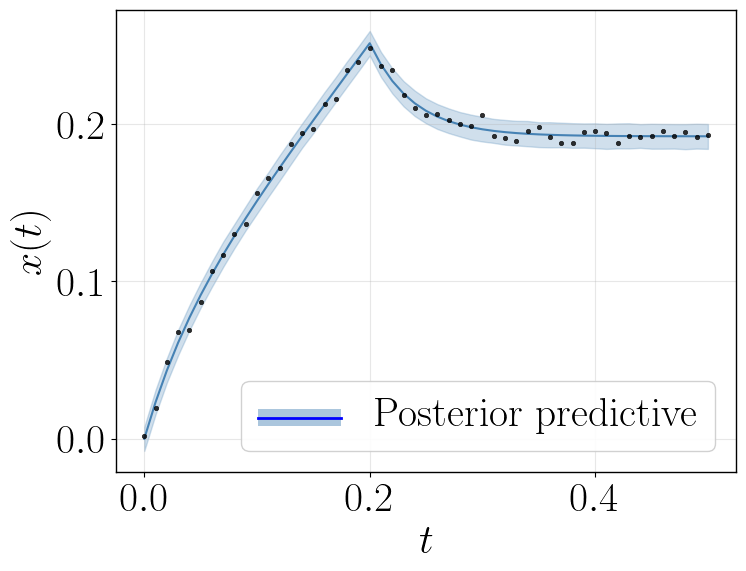

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\corner.pdf


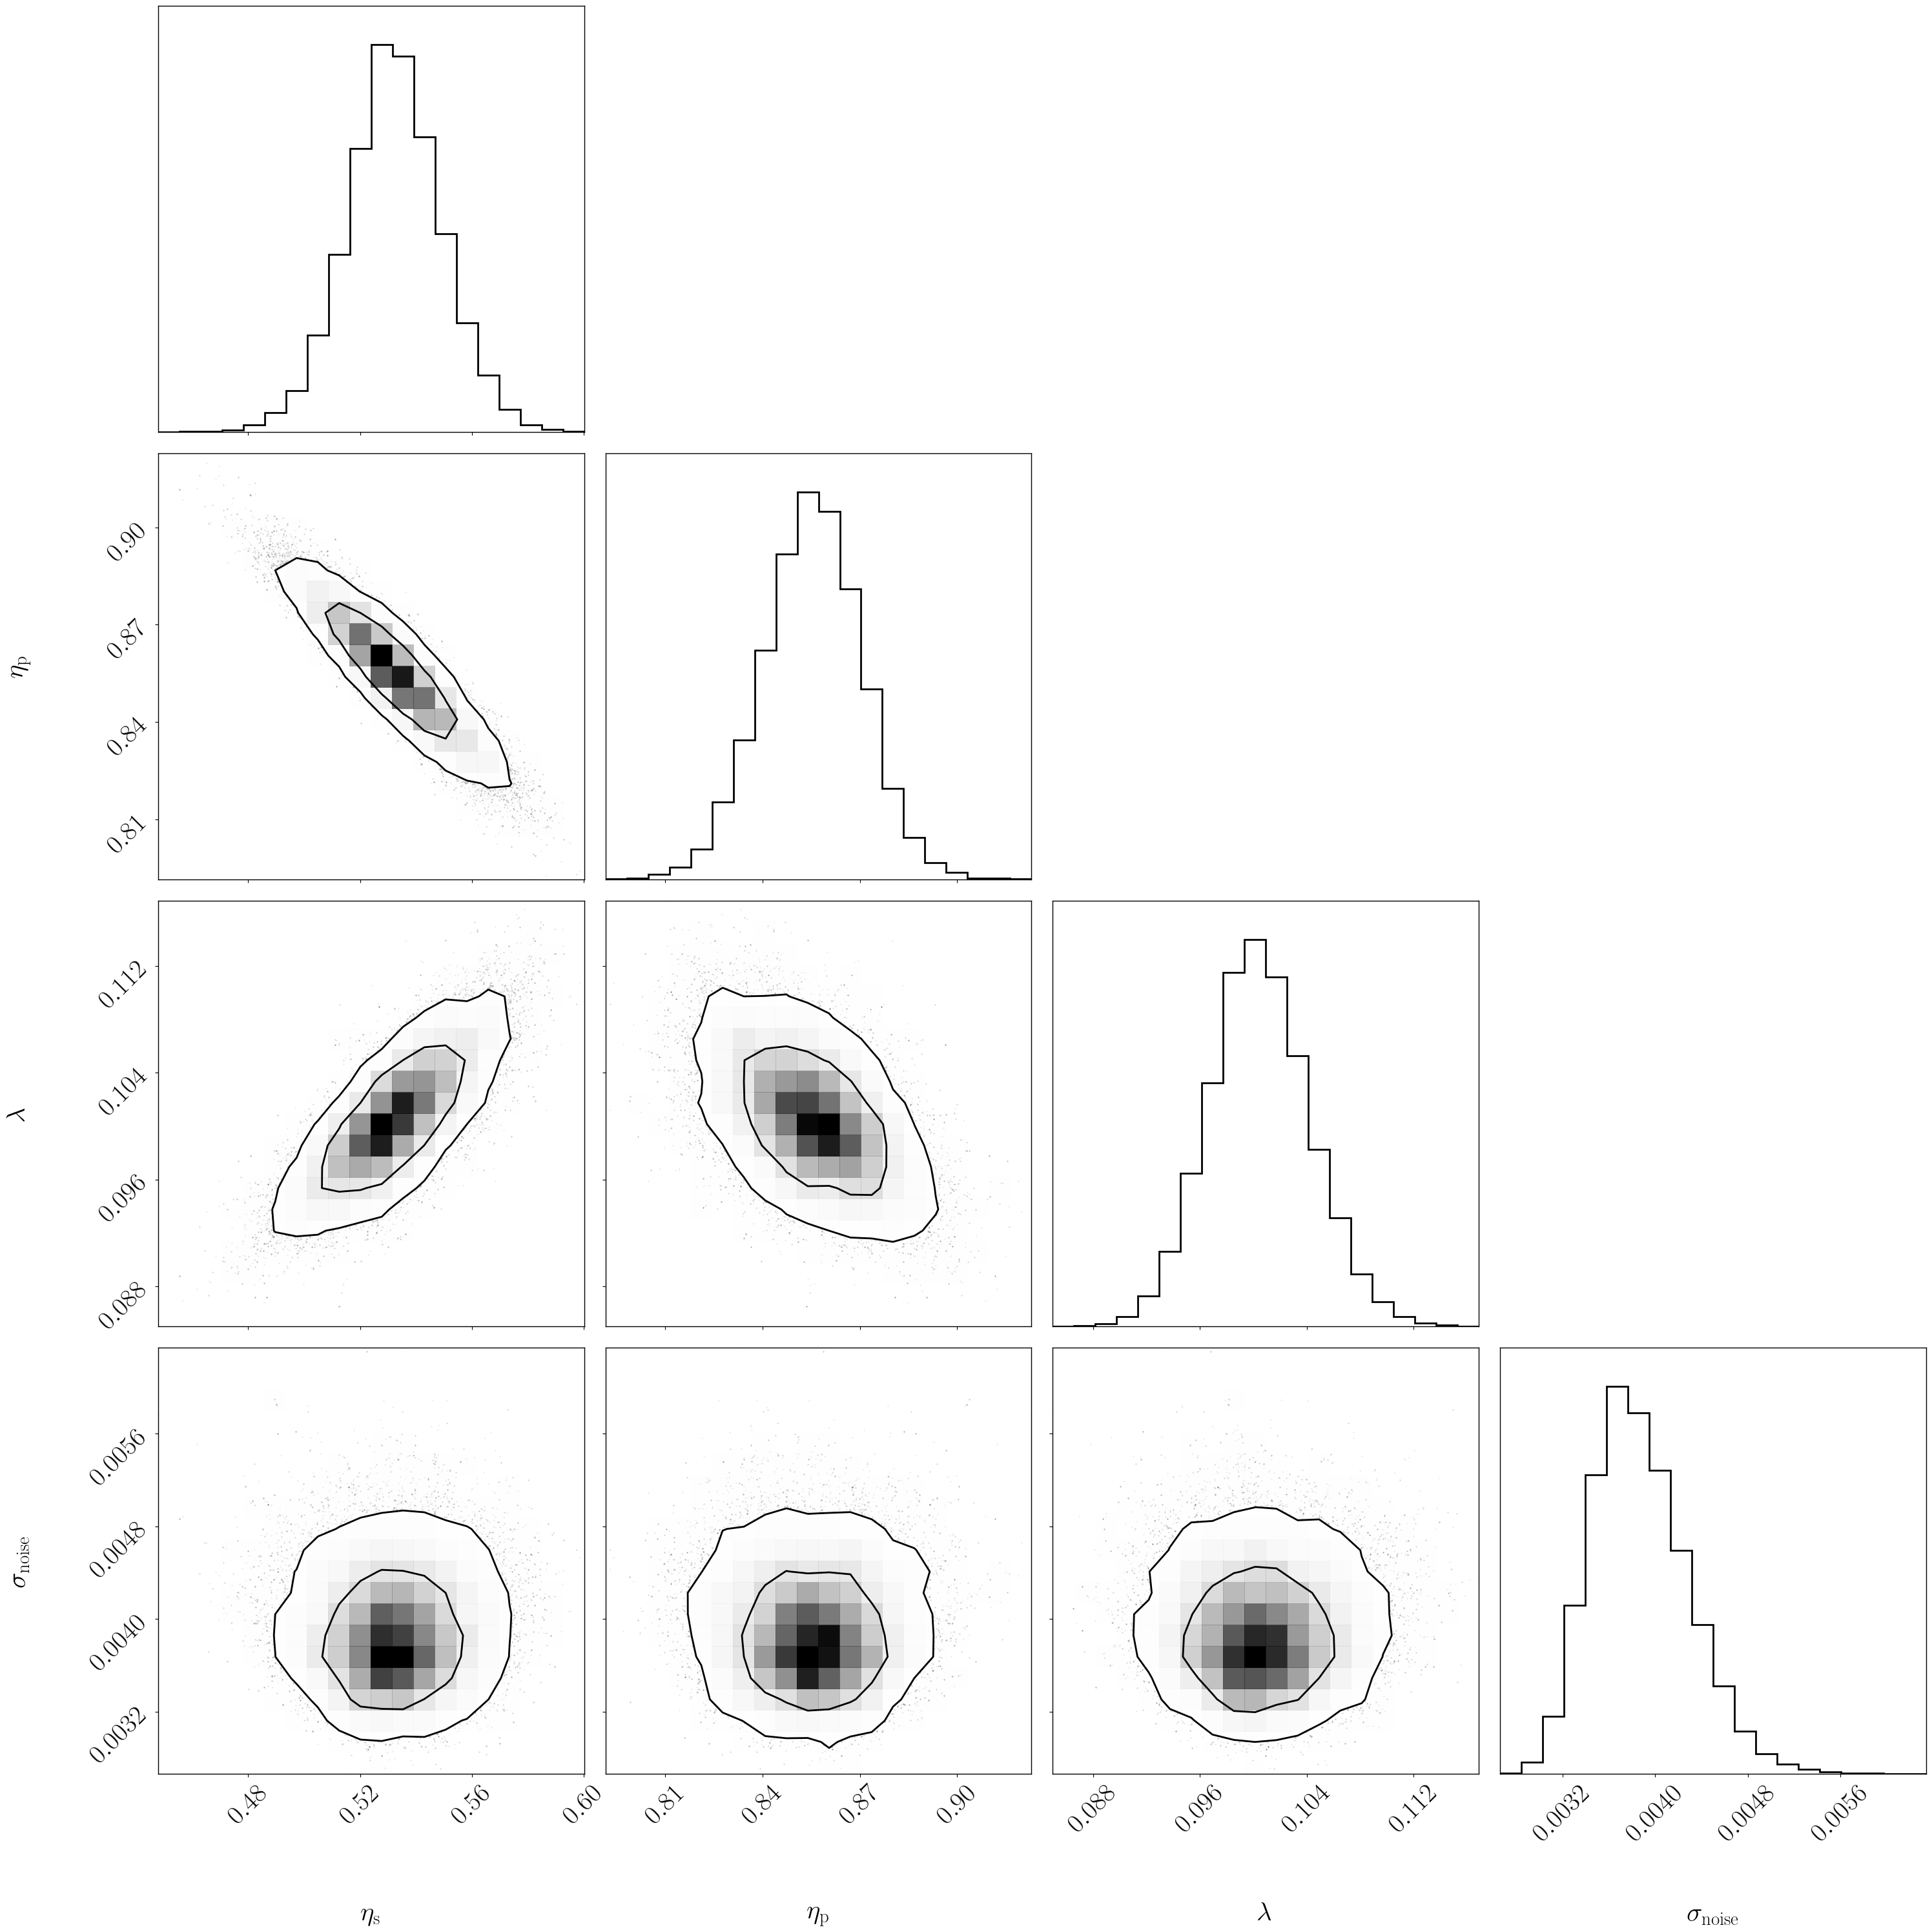

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\trace.pdf


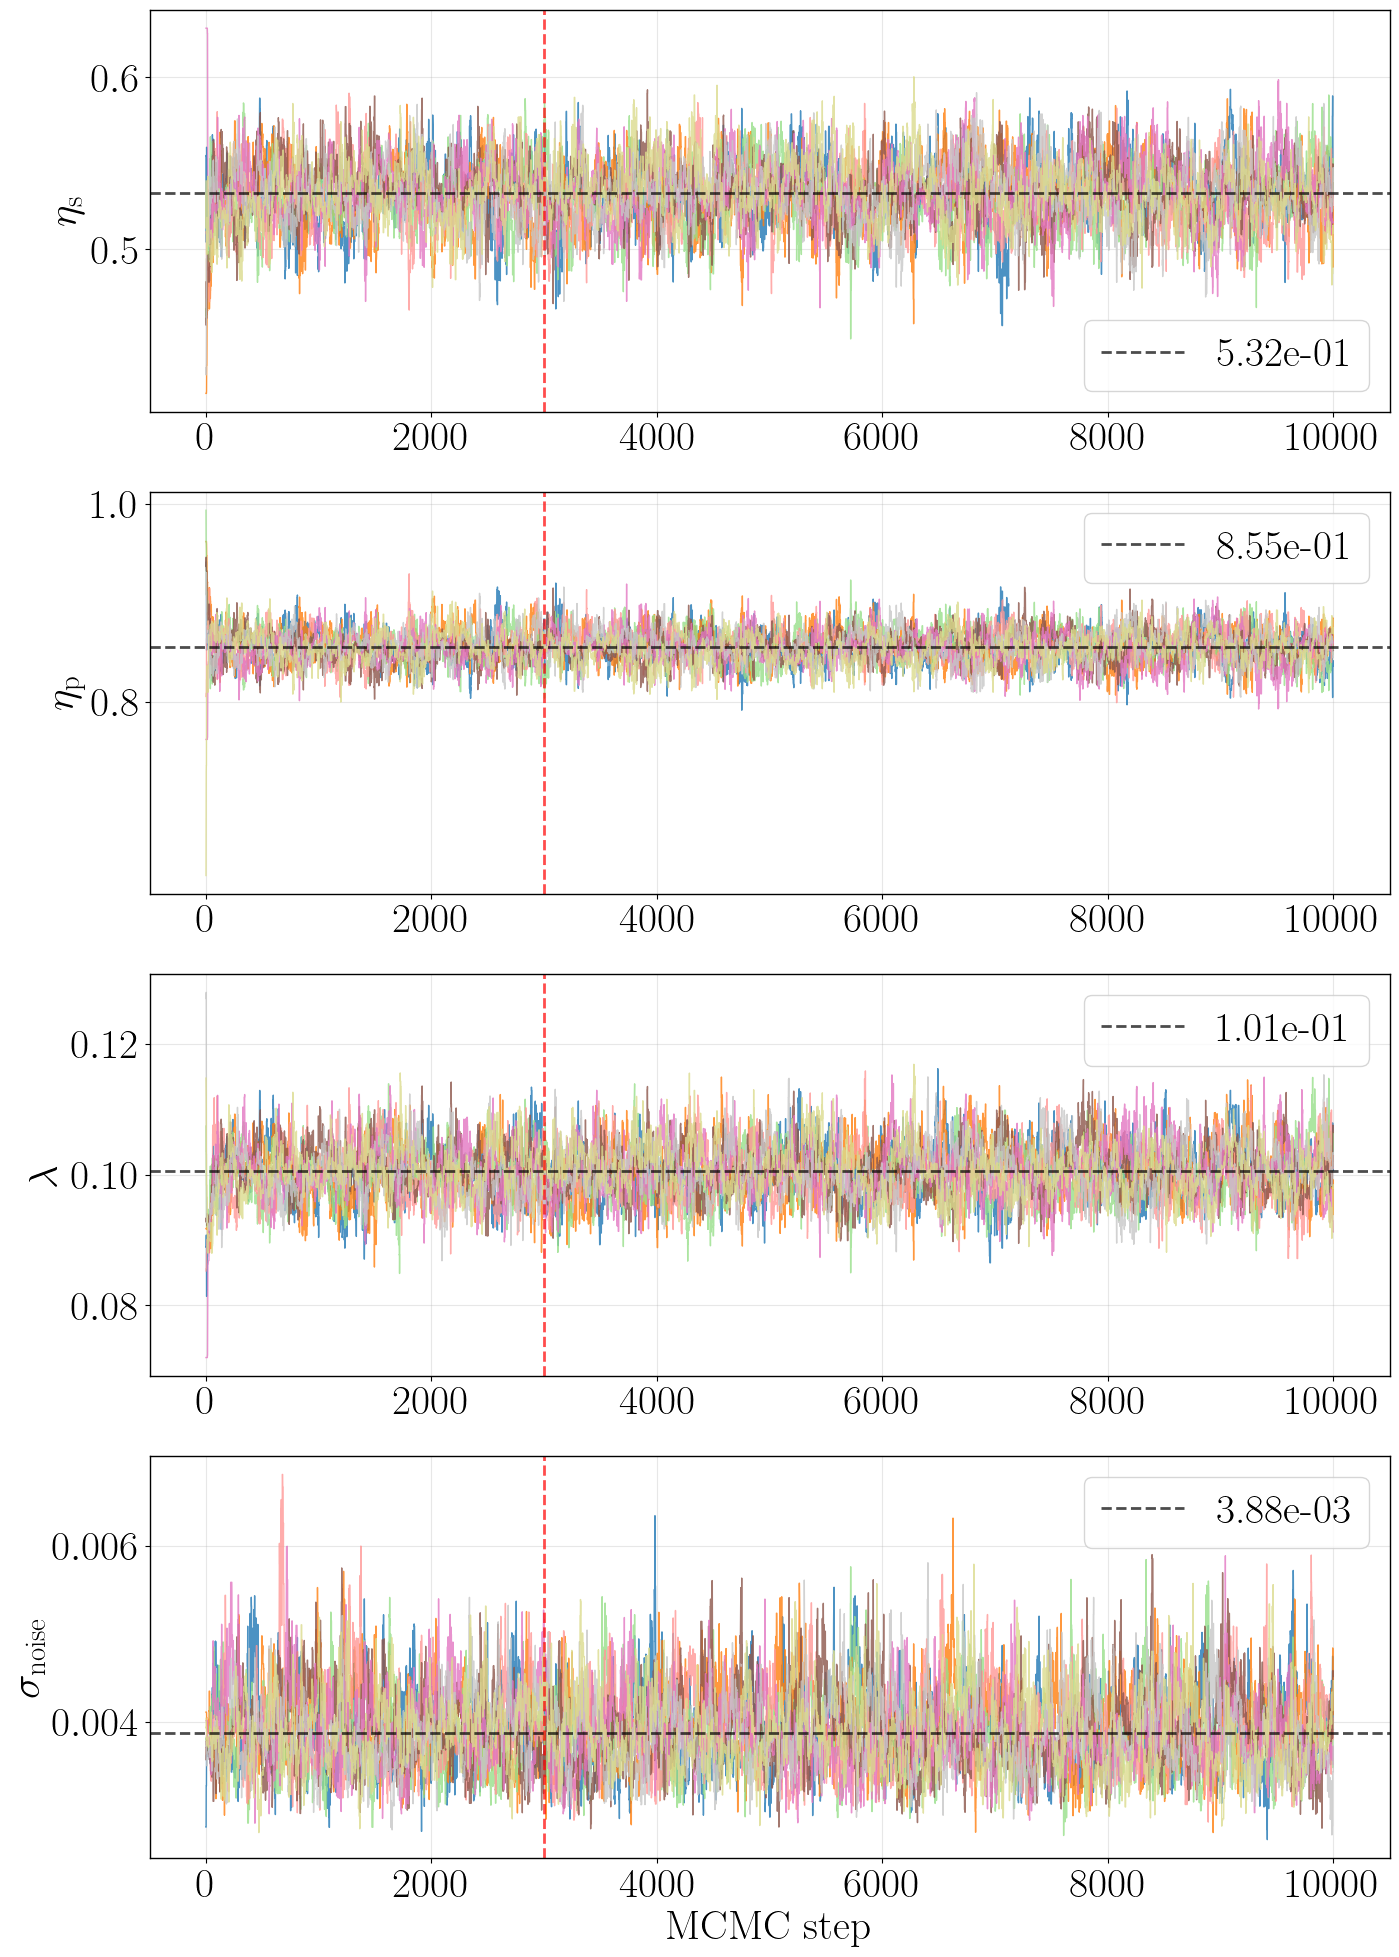

In [1]:
import sys
import os

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)

from src.main import InferenceProcedure
import numpy as np

model = InferenceProcedure(
    force = 8 * np.pi,
    material_model="viscoelastic", # "newtonian", "viscoelastic"
    boundary_model="unbounded", # "unbounded", "bounded"
    theta=0,
    t_unload=0.2,
    sigma_bias = None,
    sigma_noise_percent=2.0,
    nsteps = 10000,
    thin_factor=2)

model.load_data("linear_viscoelastic/unbounded/delta-100-0.out")
model.plot_data(theta_true=[0.5, 0.9, 0.1]) # [eta_s, eta_p, lambda]
model.plot_prior()
model.run_mcmc(init_method="kmeans", warmup = True)
model.plot_results()